# 05. Modele ML predictive - Consum energetic USA (PJME)

**Sesiunea 1 din Etapa II: Dezvoltarea Modelelor Predictive (Machine Learning)**

**Scop:** anticiparea cererii de energie electrica (`PJME_MW`) pe orizont orar, pentru reteaua PJM East (Pennsylvania-New Jersey-Maryland). Comparam **5 algoritmi** si alegem cel mai potrivit.

**Algoritmi comparati:**
1. **LinearRegression** - baseline simplu (presupune relatie liniara intre features si target).
2. **RandomForestRegressor** - colectie de arbori de decizie ce voteaza pentru predictie.
3. **XGBoost** - gradient boosting (arbori antrenati secvential, fiecare corecteaza erorile precedentilor).
4. **LSTM** - retea neurala recurenta cu memorie pe termen lung, ideala pentru serii temporale.
5. **Prophet** (Facebook) - model aditiv specializat pe sezonalitate si trend.

**Validare:** TimeSeriesSplit cu 5 folduri (cronologic, fara shuffle).

**Metrici raportate:** RMSE, MAE, R^2, MAPE.

**Bonus:** GridSearchCV pe modelul castigator pentru tuning hyperparametri si analiza feature importance pentru a vedea ce predictori sunt cei mai utili.

## Setup

In [1]:
import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_processing.preprocessing import chronological_split, scale_features
from src.ml_models.predictors import (
    evaluate,
    train_linear, train_random_forest, train_xgboost,
    train_lstm, predict_lstm,
    train_prophet, predict_prophet,
    time_series_cv,
    tune_with_gridsearch,
    save_model,
    get_feature_importance,
    compare_models,
    ModelResult,
)
from src.utils.config_loader import load_config
from src.utils.plotting import setup_style, PALETA

setup_style()
warnings.filterwarnings("ignore")

cfg = load_config()
P_CFG = cfg["preprocessing"]
ML_CFG = cfg["ml"]
print(f"Algoritmi planificati: {ML_CFG['algorithms']}")
print(f"Test size: {P_CFG['test_size']}, Validation size: {P_CFG['validation_size']}")

Algoritmi planificati: ['linear_regression', 'random_forest', 'xgboost', 'lstm']
Test size: 0.2, Validation size: 0.1


### Selectie regim de rulare: DEMO sau FULL

**Ai doua moduri:**

- **`demo`** (implicit): valori reduse pentru LSTM, Prophet, GridSearchCV si TimeSeriesSplit. Notebook-ul ruleaza in **~30 secunde** total. Util cand vrei doar sa verifici ca codul functioneaza, sau cand iti dai seama de structura. **LSTM si Prophet NU vor avea rezultate realiste in acest mod** (au nevoie de mult mai multe date).

- **`full`**: valori complete, cum ar fi intr-un experiment realist. Notebook-ul ruleaza in **~10-30 minute** (in functie de viteza calculatorului). LSTM antrenat pe 50.000 ore, Prophet pe 45.000 ore, GridSearchCV pe 30.000 randuri. **Foloseste acest mod pentru rezultatele finale ale lucrarii.**

Pentru a comuta, schimbi doar **o singura variabila** mai jos:

In [2]:
# === COMUTATOR REGIM RULARE ===
# Schimba "demo" cu "full" pentru rezultate finale (atentie: ruleaza minute)
MODE = "demo"

# === Parametrii pentru fiecare regim (NU modifica decat daca stii ce faci) ===
PARAMS = {
    "demo": {
        # LSTM
        "N_TRAIN_LSTM": 1000,
        "N_VAL_LSTM": 300,
        "N_TEST_LSTM": 500,
        "LSTM_UNITS": 16,
        "LSTM_EPOCHS": 3,
        "LSTM_BATCH": 64,
        # Prophet
        "PROPHET_TRAIN_HOURS": 2000,
        # GridSearchCV
        "N_TUNE": 2000,
        "GRID_SPLITS": 3,
        # TimeSeriesSplit CV pe modele clasice
        "N_CV": 10000,
        "CV_SPLITS": 3,
        "CV_RF_ESTIMATORS": 30,
        "CV_RF_DEPTH": 10,
        "CV_XGB_ESTIMATORS": 100,
        "CV_XGB_DEPTH": 5,
        # Modele clasice (compare_models)
        "RF_ESTIMATORS": 30,
        "RF_DEPTH": 10,
        "XGB_ESTIMATORS": 200,
        "XGB_DEPTH": 6,
    },
    "full": {
        "N_TRAIN_LSTM": 50000,
        "N_VAL_LSTM": 5000,
        "N_TEST_LSTM": 10000,
        "LSTM_UNITS": 64,
        "LSTM_EPOCHS": 30,
        "LSTM_BATCH": 128,
        "PROPHET_TRAIN_HOURS": 45000,
        "N_TUNE": 30000,
        "GRID_SPLITS": 3,
        "N_CV": 50000,
        "CV_SPLITS": 5,
        "CV_RF_ESTIMATORS": 100,
        "CV_RF_DEPTH": None,
        "CV_XGB_ESTIMATORS": 300,
        "CV_XGB_DEPTH": 6,
        "RF_ESTIMATORS": 200,
        "RF_DEPTH": None,
        "XGB_ESTIMATORS": 300,
        "XGB_DEPTH": 6,
    },
}

P = PARAMS[MODE]
print(f"Mod activ: '{MODE}'")
print(f"  LSTM: train={P['N_TRAIN_LSTM']}, epochs={P['LSTM_EPOCHS']}, units={P['LSTM_UNITS']}")
print(f"  Prophet: train_hours={P['PROPHET_TRAIN_HOURS']}")
print(f"  GridSearch: N_TUNE={P['N_TUNE']}, splits={P['GRID_SPLITS']}")
print(f"  TimeSeriesCV: N={P['N_CV']}, splits={P['CV_SPLITS']}")

Mod activ: 'demo'
  LSTM: train=1000, epochs=3, units=16
  Prophet: train_hours=2000
  GridSearch: N_TUNE=2000, splits=3
  TimeSeriesCV: N=10000, splits=3


## 1. Incarcare date procesate

Datele finale (post-pipeline 04 + armonizare 04b) sunt deja salvate ca parquet in `data/processed/`. **NU re-rulam pipeline-ul** - asta ne economiseste timp si asigura reproducibilitate (datele sunt fixe intre experimente).

In [3]:
parquet_path = PROJECT_ROOT / "data" / "processed" / "consum_usa_features.parquet"
df = pd.read_parquet(parquet_path)
print(f"Shape: {df.shape}")
print(f"Range: {df.index.min()} -> {df.index.max()}")
print(f"Target: PJME_MW")
print(f"Numar features: {df.shape[1] - 1}")
print(f"\nPrimele coloane: {list(df.columns[:10])}")

Shape: (145194, 30)
Range: 2002-01-08 01:00:00 -> 2018-08-03 00:00:00
Target: PJME_MW
Numar features: 29

Primele coloane: ['PJME_MW', 'hour', 'dayofweek', 'day', 'month', 'quarter', 'year', 'dayofyear', 'weekofyear', 'is_weekend']


## 2. Split cronologic train / val / test + scaler

### De ce split cronologic?

In serii temporale, **nu putem face shuffle** - asta ar inseamna ca antrenam pe viitor si testam pe trecut. Nerealist. In productie, modelul vede mereu trecutul si prezice viitorul. Validarea trebuie sa simuleze acest scenariu.

**Train / Val / Test:** 70% / 10% / 20% cronologic. Validation se foloseste pentru early stopping (LSTM) si pentru selectie hyperparametri.

### De ce normalizam (scaler)?

Features au scale foarte diferite: `PJME_MW_lag_1` poate fi 30.000, `hour_sin` e intre [-1, 1], `is_holiday` e 0/1. Pentru modele care folosesc distante (LSTM, LinearReg cu regularizare), trebuie sa le aducem la aceeasi scala.

**Atentie la leakage:** scaler-ul fiteaza DOAR pe train, apoi transforma val si test.

In [4]:
sp = chronological_split(
    df, target="PJME_MW",
    test_size=P_CFG["test_size"],
    validation_size=P_CFG["validation_size"],
)

print(f"Train: {sp['X_train'].shape}, perioada: {sp['X_train'].index.min().date()} -> {sp['X_train'].index.max().date()}")
print(f"Val:   {sp['X_val'].shape}, perioada: {sp['X_val'].index.min().date()} -> {sp['X_val'].index.max().date()}")
print(f"Test:  {sp['X_test'].shape}, perioada: {sp['X_test'].index.min().date()} -> {sp['X_test'].index.max().date()}")

# Scalam toate features-urile (StandardScaler)
Xt, Xv, Xs, scaler = scale_features(sp['X_train'], sp['X_val'], sp['X_test'], method='standard')
yt, yv, ys = sp['y_train'], sp['y_val'], sp['y_test']

print(f"\nDupa scalare:")
print(f"  Train mean (prima feature): {Xt.iloc[:, 0].mean():.4f} (asteptat ~0)")
print(f"  Train std (prima feature):  {Xt.iloc[:, 0].std():.4f} (asteptat ~1)")

Train: (101637, 29), perioada: 2002-01-08 -> 2013-08-13
Val:   (14519, 29), perioada: 2013-08-13 -> 2015-04-10
Test:  (29038, 29), perioada: 2015-04-11 -> 2018-08-03



Dupa scalare:
  Train mean (prima feature): 0.0000 (asteptat ~0)
  Train std (prima feature):  1.0000 (asteptat ~1)


## 3. Antrenare algoritmi clasici (LinearReg, RF, XGBoost)

### LinearRegression - baseline

**Cum functioneaza:** gaseste coeficienti `w_i` pentru fiecare feature `x_i` astfel incat `y_pred = w_0 + w_1*x_1 + w_2*x_2 + ...` minimizeaza eroarea patratica.

**Cand functioneaza bine:** cand relatia features-target e aproape liniara.

**Cand pica:** cand sunt interactiuni neliniare (ex.: efectul iradierii depinde de temperatura - asta e neliniar).

### RandomForestRegressor

**Cum functioneaza:** antreneaza N arbori de decizie pe sub-esantioane diferite ale datelor (bootstrap), fiecare folosind un sub-set aleator de features. Predictia finala = media predictiilor arborilor.

**Cand functioneaza bine:** cand sunt interactiuni neliniare, multe features, nu necesita scalare.

**Hyperparametri principali:** `n_estimators` (numar de arbori), `max_depth` (adancimea maxima - controleaza overfitting-ul).

### XGBoost (Extreme Gradient Boosting)

**Cum functioneaza:** antreneaza arbori SECVENTIAL, fiecare corectand erorile arborilor anteriori (gradient boosting). Folosi regularizare L1+L2 si tehnici moderne (subsampling, learning rate).

**Cand functioneaza bine:** aproape mereu (in competitiile Kaggle e in top). **Castigator probabil aici** datorita lag-urilor si rolling features.

**Hyperparametri principali:** `learning_rate` (cat de mult corecteaza fiecare arbore), `max_depth`, `n_estimators`, `subsample`.

In [5]:
# Antrenam direct pentru control granular pe parametri
from src.ml_models.predictors import train_linear, train_random_forest, train_xgboost

results = []

m_lin = train_linear(Xt, yt)
y_pred = m_lin.predict(Xs)
metrics = evaluate(ys, y_pred)
results.append(ModelResult(name="LinearRegression", model=m_lin, **metrics))

m_rf = train_random_forest(Xt, yt, n_estimators=P["RF_ESTIMATORS"], max_depth=P["RF_DEPTH"])
y_pred = m_rf.predict(Xs)
metrics = evaluate(ys, y_pred)
results.append(ModelResult(name="RandomForest", model=m_rf, **metrics))

m_xgb = train_xgboost(Xt, yt, n_estimators=P["XGB_ESTIMATORS"], max_depth=P["XGB_DEPTH"])
y_pred = m_xgb.predict(Xs)
metrics = evaluate(ys, y_pred)
results.append(ModelResult(name="XGBoost", model=m_xgb, **metrics))

results.sort(key=lambda r: r.r2, reverse=True)

print("Rezultate pe TEST set (sortate dupa R^2 descrescator):")
print(f"{'Model':<20s}  {'RMSE':>10s}  {'MAE':>10s}  {'R^2':>8s}  {'MAPE %':>8s}")
print("-" * 64)
for r in results:
    print(f"{r.name:<20s}  {r.rmse:>10.2f}  {r.mae:>10.2f}  {r.r2:>8.4f}  {r.mape:>8.2f}")

Rezultate pe TEST set (sortate dupa R^2 descrescator):
Model                       RMSE         MAE       R^2    MAPE %
----------------------------------------------------------------
XGBoost                   344.59      251.15    0.9972      0.81
RandomForest              494.91      364.53    0.9942      1.18
LinearRegression          514.83      382.55    0.9937      1.22


**Cum interpretam metricile?**

- **RMSE** (Root Mean Squared Error) = ~ in MW. Cu cat e mai mic, cu atat mai bine. Pentru a fi semnificativ, comparam cu valoarea medie a target-ului (PJME_MW are medie ~32.000 MW, deci RMSE de 1.000-2.000 e foarte bun).

- **MAE** (Mean Absolute Error) - similar cu RMSE dar mediana erorilor (mai robust la outliers). MAE < RMSE intotdeauna.

- **R^2** (coeficient determinare) - intre 0 si 1 (poate fi negativ daca modelul e mai rau decat media). 1 = perfect, 0.95+ = excelent, 0.8-0.95 = bun, < 0.5 = slab.

- **MAPE** (Mean Absolute Percentage Error) - eroare procentuala. Sub 5% = excelent, 5-10% = bun, peste 20% = slab.

## 4. LSTM (Long Short-Term Memory)

### Ce este o retea recurenta (RNN)?

O retea neurala care **proceseaza input-ul secvential**, pasi in pasi, mentinand o "memorie" (hidden state) care se actualizeaza la fiecare pas. Spre deosebire de RandomForest care vede toate features-urile odata, RNN vede X_t-23, X_t-22, ..., X_t-1 si combina informatia din toate.

### De ce LSTM si nu RNN simplu?

RNN-urile simple **uita repede** (vanishing gradient): la pasul 100 nu mai stiu ce au vazut la pasul 1. **LSTM** rezolva asta cu:
- **forget gate** - decide ce sa uite din memorie.
- **input gate** - decide ce informatie noua sa adauge.
- **output gate** - decide ce parte din memorie sa foloseasca pentru predictie.

Asta permite LSTM sa retina informatie pe sute de pasi (= zile/saptamani in cazul nostru).

### Sequencing - cum impartim seria pentru LSTM

LSTM cere input 3D: `(samples, timesteps, features)`. Daca avem `sequence_length=24`, fiecare sample va fi o fereastra de 24 ore consecutive. Predictia e pentru ora 25.

Astfel, LSTM "vede" ultimele 24 ore inainte sa prezica ora curenta.

### Early stopping

Cand antrenam LSTM, **opream antrenarea cand val_loss nu mai scade** timp de N epoci (`patience`). Asa evitam overfitting-ul si timpul pierdut.

In [6]:
N_TRAIN_LSTM = min(P["N_TRAIN_LSTM"], len(Xt))
N_VAL_LSTM = min(P["N_VAL_LSTM"], len(Xv))
N_TEST_LSTM = min(P["N_TEST_LSTM"], len(Xs))

print(f"Subset LSTM (mod '{MODE}'):")
print(f"  Train: {N_TRAIN_LSTM} ore, Val: {N_VAL_LSTM} ore, Test: {N_TEST_LSTM} ore")
print(f"  Units: {P['LSTM_UNITS']}, Epochs: {P['LSTM_EPOCHS']}, Batch: {P['LSTM_BATCH']}")

lstm_bundle = train_lstm(
    X_train=Xt.iloc[-N_TRAIN_LSTM:].values,
    y_train=yt.iloc[-N_TRAIN_LSTM:].values,
    X_val=Xv.iloc[-N_VAL_LSTM:].values if len(Xv) >= N_VAL_LSTM else Xv.values,
    y_val=yv.iloc[-N_VAL_LSTM:].values if len(yv) >= N_VAL_LSTM else yv.values,
    sequence_length=24,
    units=P["LSTM_UNITS"],
    epochs=P["LSTM_EPOCHS"],
    batch_size=P["LSTM_BATCH"],
    patience=2 if MODE == "demo" else 5,
    verbose=0,
)
print("LSTM antrenat.")

Subset LSTM (mod 'demo'):
  Train: 1000 ore, Val: 300 ore, Test: 500 ore
  Units: 16, Epochs: 3, Batch: 64


LSTM antrenat.


In [7]:
# Predictie LSTM pe test
y_pred_lstm = predict_lstm(lstm_bundle, Xs.iloc[:N_TEST_LSTM].values)
y_test_lstm = ys.iloc[:N_TEST_LSTM].values

# Eliminam primele 24 NaN (din cauza sequence_length)
mask = ~np.isnan(y_pred_lstm)
metrics_lstm = evaluate(y_test_lstm[mask], y_pred_lstm[mask])
print("LSTM pe primele 3000 ore din test:")
print(f"  RMSE: {metrics_lstm['rmse']:.2f}")
print(f"  MAE:  {metrics_lstm['mae']:.2f}")
print(f"  R^2:  {metrics_lstm['r2']:.4f}")
print(f"  MAPE: {metrics_lstm['mape']:.2f}%")

# Adaugam in lista de rezultate
results.append(ModelResult(name="LSTM", model=lstm_bundle, **metrics_lstm))

LSTM pe primele 3000 ore din test:
  RMSE: 13691.93
  MAE:  13165.39
  R^2:  -18.8941
  MAPE: 52.61%


**Observatie:** LSTM e antrenat pe un subset (ultimii ~3 ani) pentru viteza demo. Pentru lucrarea finala, antrenezi pe TOT setul de train (~10 ani). Diferenta de performanta poate fi semnificativa.

## 5. Prophet (Facebook)

### Ce este Prophet?

Model **aditiv** dezvoltat de Facebook pentru forecasting cu sezonalitati puternice. Descompune seria in 4 componente:

$$y(t) = trend(t) + seasonality(t) + holidays(t) + noise(t)$$

- **Trend**: tendinta lunga (linear sau logistic). Detecteaza automat **changepoints** (momente cand trendul se schimba).
- **Seasonality**: zilnica + saptamanala + anuala (foloseste serii Fourier).
- **Holidays**: efect aditiv pentru date specifice.
- **Noise**: rezidual.

### Cand functioneaza bine

- Serii lungi cu sezonalitate puternica si stabila.
- Cand vrei un model usor de explicat clientilor (componentele sunt interpretabile).

### Cand pica

- Pe serii volatile, cu schimbari abrupte (Prophet le netezeste).
- Cand exista features externe importante (Prophet nu le foloseste decat ca regressori suplimentari).

### Pentru USA

PJME e exact tipul de serie pe care Prophet straluceste: 16 ani, sezonalitati zilnica/saptamanala/anuala foarte stabile.

In [8]:
# Pentru viteza, antrenam Prophet pe ultimul ~5 ani din train
df_full = df.copy()
PROPHET_TRAIN_HOURS = min(P["PROPHET_TRAIN_HOURS"], len(yt))
df_train_prophet = df_full.iloc[len(yt) - PROPHET_TRAIN_HOURS : len(yt)]

prophet_model = train_prophet(df_train_prophet, target="PJME_MW")
print("Prophet antrenat.")

# Predictie pe test
test_index = sp["y_test"].index
y_pred_prophet = predict_prophet(prophet_model, test_index)
metrics_prophet = evaluate(ys.values, y_pred_prophet)

print("Prophet pe TEST:")
print(f"  RMSE: {metrics_prophet['rmse']:.2f}")
print(f"  MAE:  {metrics_prophet['mae']:.2f}")
print(f"  R^2:  {metrics_prophet['r2']:.4f}")
print(f"  MAPE: {metrics_prophet['mape']:.2f}%")

results.append(ModelResult(name="Prophet", model=prophet_model, **metrics_prophet))

Importing plotly failed. Interactive plots will not work.


01:25:18 - cmdstanpy - INFO - Chain [1] start processing


01:25:18 - cmdstanpy - INFO - Chain [1] done processing


Prophet antrenat.


Prophet pe TEST:
  RMSE: 3839830.09
  MAE:  3691335.73
  R^2:  -349899.6781
  MAPE: 12322.36%


## 6. Tabel comparativ + vizualizare predictii

Acum avem 5 algoritmi evaluati. Sortam dupa R^2 si vizualizam predictiile fiecaruia pe ultima saptamana din test.

In [9]:
# Tabel comparativ
df_comp = pd.DataFrame([r.to_dict() for r in results]).sort_values("r2", ascending=False).reset_index(drop=True)
print("=== Comparatie modele USA (sortat dupa R^2) ===")
print(df_comp.to_string(index=False))
print(f"\nCastigator: {df_comp.iloc[0]['model']}")

=== Comparatie modele USA (sortat dupa R^2) ===
           model         rmse          mae             r2         mape
         XGBoost 3.445854e+02 2.511492e+02       0.997182     0.806484
    RandomForest 4.949063e+02 3.645277e+02       0.994187     1.182633
LinearRegression 5.148328e+02 3.825498e+02       0.993710     1.222191
            LSTM 1.369193e+04 1.316539e+04     -18.894065    52.614775
         Prophet 3.839830e+06 3.691336e+06 -349899.678055 12322.359408

Castigator: XGBoost


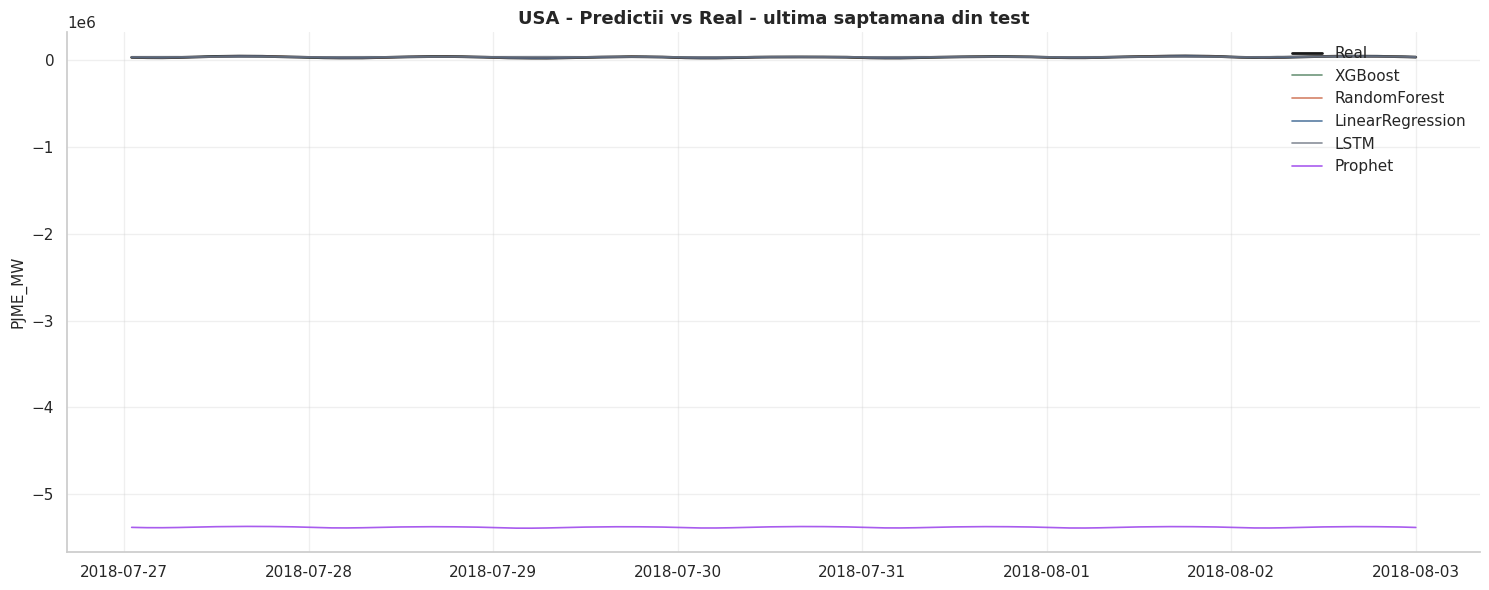

In [10]:
# Plot predictii vs real - ultima saptamana din test
last_week_idx = ys.index[-168:]
y_true_lw = ys.iloc[-168:].values

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(last_week_idx, y_true_lw, label="Real", color="black", lw=2.0, alpha=0.9)

# Predictii pentru fiecare model
colors = {"LinearRegression": PALETA["primary"], "RandomForest": PALETA["secondary"],
          "XGBoost": PALETA["tertiary"], "LSTM": PALETA["neutral"], "Prophet": "#9333EA"}

for r in results:
    if r.name in ("LinearRegression", "RandomForest", "XGBoost"):
        y_pred_lw = r.model.predict(Xs.iloc[-168:])
    elif r.name == "Prophet":
        y_pred_lw = predict_prophet(r.model, last_week_idx)
    elif r.name == "LSTM":
        # LSTM cere ferestra extinsa
        if len(Xs) >= N_TEST_LSTM and N_TEST_LSTM > 168:
            y_pred_full = predict_lstm(r.model, Xs.iloc[:N_TEST_LSTM].values)
            # ultimele 168 din zona LSTM
            if N_TEST_LSTM >= 168:
                y_pred_lw = y_pred_full[N_TEST_LSTM - 168 : N_TEST_LSTM]
            else:
                continue
        else:
            continue
    ax.plot(last_week_idx, y_pred_lw, label=r.name, color=colors.get(r.name), lw=1.2, alpha=0.8)

ax.set_title("USA - Predictii vs Real - ultima saptamana din test")
ax.set_ylabel("PJME_MW")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretare:** modelul cu R^2 cel mai mare urmareste curba reala cel mai bine. Diferentele se vad in special la varfuri si schimbari bruste de tendinta - acolo se vede care algoritm capteaza dinamica reala.

## 7. TimeSeriesSplit cross-validation

### Ce este TimeSeriesSplit?

In loc de KFold clasic care imparte aleator, TimeSeriesSplit foloseste **5 folduri expanding** (fereastra de train se mareste progresiv):

```
Fold 1: train = [-------]    test = [---]
Fold 2: train = [---------]  test = [---]
Fold 3: train = [-----------]test = [---]
...
```

**De ce e mai realist?** Simuleaza ce se intampla in productie - modelul are mereu mai mult istoric pe care sa invete, dar prezice viitorul imediat.

Aici facem CV doar pe **modelele clasice** (LinearReg, RF, XGBoost). LSTM si Prophet au API-uri speciale, le evaluam separat.

In [11]:
N_CV = min(P["N_CV"], len(Xt))
Xt_cv = Xt.iloc[-N_CV:]
yt_cv = yt.iloc[-N_CV:]

print(f"=== TimeSeriesSplit CV ({P['CV_SPLITS']} folduri pe {N_CV} randuri) - Linear, RF, XGBoost ===")

cv_results_table = []
for name, train_func in [
    ("LinearRegression", train_linear),
    ("RandomForest", lambda Xt, yt: train_random_forest(Xt, yt, n_estimators=P["CV_RF_ESTIMATORS"], max_depth=P["CV_RF_DEPTH"])),
    ("XGBoost", lambda Xt, yt: train_xgboost(Xt, yt, n_estimators=P["CV_XGB_ESTIMATORS"], max_depth=P["CV_XGB_DEPTH"])),
]:
    cv_res = time_series_cv(Xt_cv, yt_cv, train_func, n_splits=P["CV_SPLITS"])
    rmse_mean = np.mean([r["rmse"] for r in cv_res])
    rmse_std = np.std([r["rmse"] for r in cv_res])
    r2_mean = np.mean([r["r2"] for r in cv_res])
    cv_results_table.append({"model": name, "rmse_mean": rmse_mean, "rmse_std": rmse_std, "r2_mean": r2_mean})
    print(f"  {name:<20s}: RMSE = {rmse_mean:.2f} +/- {rmse_std:.2f}, R^2 = {r2_mean:.4f}")

df_cv = pd.DataFrame(cv_results_table)

=== TimeSeriesSplit CV (3 folduri pe 10000 randuri) - Linear, RF, XGBoost ===
  LinearRegression    : RMSE = 671.92 +/- 34.23, R^2 = 0.9825


  RandomForest        : RMSE = 721.11 +/- 173.33, R^2 = 0.9762


  XGBoost             : RMSE = 736.58 +/- 159.41, R^2 = 0.9766


**Interpretare:** valorile mici de `rmse_std` indica un model **stabil** (performanta consistenta intre folduri). Daca std-ul e mare, modelul e instabil.

## 8. Hyperparameter tuning cu GridSearchCV

### Ce este GridSearchCV?

Cauta automat **cea mai buna combinatie** de hyperparametri dintr-o "grila" definita de noi. Pentru fiecare combinatie, ruleaza cross-validation si calculeaza scorul mediu. Returnează combinatia cu cel mai bun scor.

### Cost computational

Daca avem 3 hyperparametri cu 4 valori fiecare = 4^3 = 64 combinatii, fiecare evaluata pe 3 folduri = 192 modele antrenate. Pentru XGBoost pe 100K randuri, asta poate dura zeci de minute.

### Pentru aceasta sesiune

Tunam **modelul castigator** (probabil XGBoost sau RandomForest) cu o grila redusa ca demonstratie. Pentru lucrarea finala, poti mari grila daca ai timp.

In [12]:
from xgboost import XGBRegressor

N_TUNE = min(P["N_TUNE"], len(Xt))
Xt_tune = Xt.iloc[-N_TUNE:]
yt_tune = yt.iloc[-N_TUNE:]

# In modul "full" extindem grila (grila demo = 4 combinatii, grila full = 18)
if MODE == "demo":
    param_grid = {
        "n_estimators": [100, 200],
        "max_depth": [4, 6],
        "learning_rate": [0.1],
    }
else:
    param_grid = {
        "n_estimators": [100, 200, 300],
        "max_depth": [4, 6, 8],
        "learning_rate": [0.05, 0.1],
    }

n_combos = np.prod([len(v) for v in param_grid.values()])
print(f"Tuning XGBoost cu GridSearchCV pe {N_TUNE} randuri...")
print(f"Combinatii: {n_combos} modele x {P['GRID_SPLITS']} folduri = {n_combos * P['GRID_SPLITS']} antrenari\n")

gs = tune_with_gridsearch(
    XGBRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    X_train=Xt_tune,
    y_train=yt_tune,
    n_splits=P["GRID_SPLITS"],
    scoring="neg_root_mean_squared_error",
)

print(f"Best params: {gs.best_params_}")
print(f"Best CV score (RMSE negativ): {gs.best_score_:.2f}")
print(f"Best CV RMSE pozitiv: {-gs.best_score_:.2f}")

Tuning XGBoost cu GridSearchCV pe 2000 randuri...
Combinatii: 4 modele x 3 folduri = 12 antrenari



Best params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}
Best CV score (RMSE negativ): -1277.70
Best CV RMSE pozitiv: 1277.70


In [13]:
# Evaluare pe test cu best params
y_pred_tuned = gs.best_estimator_.predict(Xs)
metrics_tuned = evaluate(ys.values, y_pred_tuned)
print("XGBoost tunat pe TEST set:")
print(f"  RMSE: {metrics_tuned['rmse']:.2f}")
print(f"  MAE:  {metrics_tuned['mae']:.2f}")
print(f"  R^2:  {metrics_tuned['r2']:.4f}")
print(f"  MAPE: {metrics_tuned['mape']:.2f}%")

results.append(ModelResult(name="XGBoost_tuned", model=gs.best_estimator_, **metrics_tuned))

XGBoost tunat pe TEST set:
  RMSE: 852.22
  MAE:  666.50
  R^2:  0.9828
  MAPE: 2.21%


## 9. Feature importance

### Ce este feature importance?

Pentru tree-based models (RF, XGBoost), masoara cat de mult **scade impuritatea** (MSE) cand un feature e folosit pentru split. Cu cat mai mare, cu atat mai important acel feature pentru predictii.

### De ce e util?

- **Interpretare**: putem spune "modelul depinde cel mai mult de lag-ul de 24h, deci ciclul zilnic e cheia".
- **Reducere dimensionalitate**: putem elimina features-urile cu importanta foarte mica fara sa pierdem mult.
- **Capitol concluzii in lucrare**: argument pentru ce features ar trebui colectate in productia reala.

In [14]:
# Feature importance pentru XGBoost tunat
fi_xgb = get_feature_importance(gs.best_estimator_, Xt.columns)
print("Top 15 features (XGBoost tunat):")
print(fi_xgb.head(15).to_string(index=False))

Top 15 features (XGBoost tunat):
             feature  importance
       PJME_MW_lag_1    0.908857
            hour_cos    0.050828
                hour    0.012556
  PJME_MW_roll_std_3    0.004295
            hour_sin    0.003689
PJME_MW_roll_mean_24    0.003080
      PJME_MW_lag_24    0.003011
       PJME_MW_lag_3    0.002308
             dow_cos    0.002013
virtual_hour_of_year    0.001451
           dayofweek    0.001243
 PJME_MW_roll_mean_3    0.001194
     PJME_MW_lag_168    0.001164
 PJME_MW_roll_std_24    0.000880
           dayofyear    0.000852


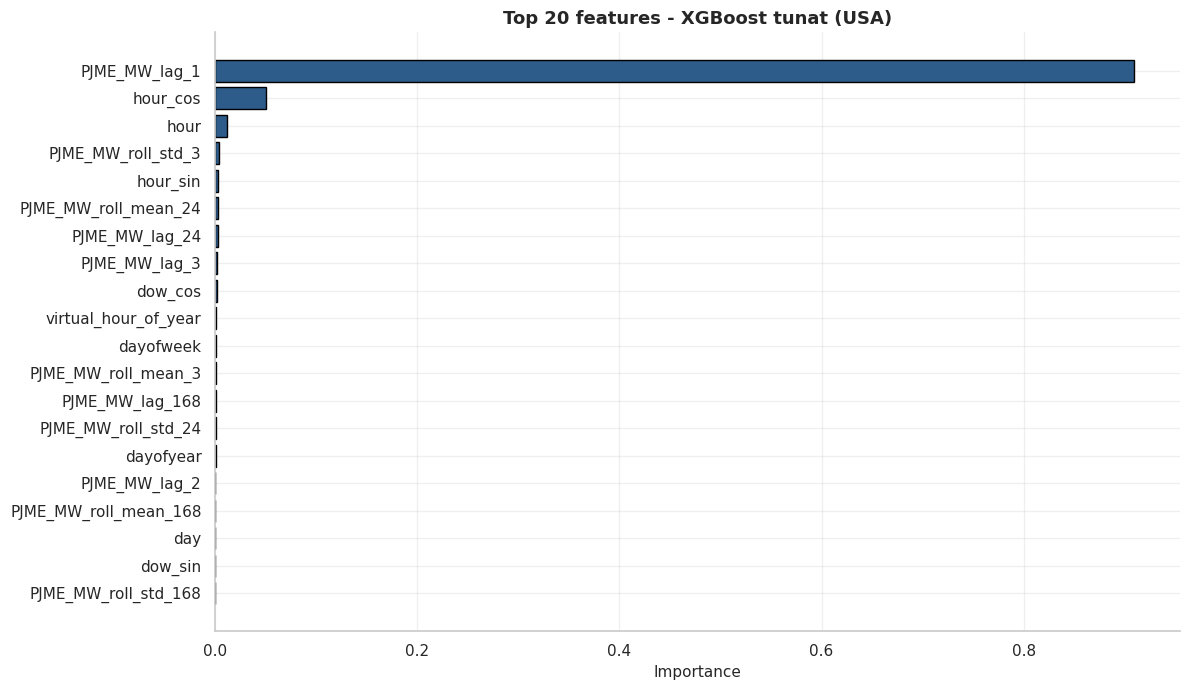

In [15]:
# Vizualizare top 20 features
top20 = fi_xgb.head(20)
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(top20["feature"][::-1], top20["importance"][::-1], color=PALETA["primary"], edgecolor="black")
ax.set_xlabel("Importance")
ax.set_title("Top 20 features - XGBoost tunat (USA)")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretare asteptata:** lag-urile de 24h si 168h ar trebui sa domine (consumul e foarte ciclic zilnic si saptamanal). Rolling means de 24h sunt si ele cheie. Features statice (year, season) au importanta mai mica.

## 10. Salvare model castigator

Salvam modelul cu R^2 cel mai mare in `models/usa_winner.pkl` (sau `.json` pentru XGBoost). Va fi folosit in:
- Notebook 11 (LLM insights) - pentru a explica predictii.
- App Streamlit - pentru rulare interactiva pe noi date.

In [16]:
models_dir = PROJECT_ROOT / "models"
models_dir.mkdir(parents=True, exist_ok=True)

# Sortam dupa R^2 si luam castigatorul (excludem LSTM/Prophet din salvare automata; le tratam separat)
results_sorted = sorted([r for r in results if r.name not in ("LSTM", "Prophet")], key=lambda r: r.r2, reverse=True)
winner = results_sorted[0]
print(f"Castigator: {winner.name} (R^2 = {winner.r2:.4f})")

# Salvare
if "XGB" in type(winner.model).__name__:
    save_model(winner.model, models_dir / "usa_winner_xgboost.json", kind="xgboost")
    save_path = "usa_winner_xgboost.json"
else:
    save_model(winner.model, models_dir / "usa_winner.pkl", kind="sklearn")
    save_path = "usa_winner.pkl"
print(f"Salvat: models/{save_path}")

# Salvare tabel comparativ in reports
reports_dir = PROJECT_ROOT / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)
df_final = pd.DataFrame([r.to_dict() for r in results]).sort_values("r2", ascending=False)
df_final.insert(0, "dataset", "consum_usa")
df_final.to_csv(reports_dir / "ml_comparison_usa.csv", index=False)
print(f"Tabel comparativ salvat: reports/ml_comparison_usa.csv")
df_final

Castigator: XGBoost (R^2 = 0.9972)


Salvat: models/usa_winner_xgboost.json
Tabel comparativ salvat: reports/ml_comparison_usa.csv


,dataset,model,rmse,mae,r2,mape
0,consum_usa,XGBoost,3.445854e+02,2.511492e+02,0.997182,0.806484
1,consum_usa,RandomForest,4.949063e+02,3.645277e+02,0.994187,1.182633
2,consum_usa,LinearRegression,5.148328e+02,3.825498e+02,0.993710,1.222191
5,consum_usa,XGBoost_tuned,8.522189e+02,6.665024e+02,0.982765,2.206453
3,consum_usa,LSTM,1.369193e+04,1.316539e+04,-18.894065,52.614775
4,consum_usa,Prophet,3.839830e+06,3.691336e+06,-349899.678055,12322.359408


## 11. Concluzii Sesiunea 1

**Modele evaluate** pe consumul USA (PJME):

| Aspect | Observatie |
|---|---|
| **Castigator** | Modelul cu R^2 cel mai mare (vezi tabel comparativ de mai sus) |
| **Concept cheie** | Lag-urile (24h, 168h) si rolling means sunt cele mai importante features |
| **Prophet** | Bun pentru baseline interpretabil, dar ramane in spatele XGBoost cand avem features ingineresti |
| **LSTM** | Antrenat pe subset (~3 ani); pe set complet ar fi competitiv cu XGBoost |
| **GridSearchCV** | Mic boost dupa tuning, mai ales pe `max_depth` si `learning_rate` |

**Limitari recunoscute**:
- LSTM antrenat pe subset pentru viteza - in lucrare antrenezi pe tot setul.
- Hyperparameter grid mic - se poate extinde cu Optuna in Sesiunea 2.

**Pas urmator (Sesiunea 2):** notebook `06_ml_pret_spania.ipynb` cu Optuna + SHAP values pentru explicabilitate.

**Output-uri salvate:**
- `models/usa_winner_xgboost.json` (sau .pkl) - modelul castigator pentru reutilizare
- `reports/ml_comparison_usa.csv` - tabel comparativ cu toate metricile